In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

import superstats as sup
import bayesflow as bf

import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/miniconda3/envs/bf_jax/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


- Proper defaults for all priors
- Discuss best practice for defaults
    + e.g. plotting
    + what about default and then check if none and set default

## Specify Prior

In [72]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(-1.0, 1.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.05),
            delta=sup.prior.Prior(dist="halfnormal", scale=0.005),
            initial_prior=sup.prior.Prior(dist="normal", low=0.0, high=1.0)
        ),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.AutoRegression(),
            sup.transition.Jump()
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[15.0, 1.5]),
        bounds=(0.0, 4.0)
    ),
    bias = 0.5,
    tau = sup.prior.Prior(dist="halfnormal", scale=0.15)
)

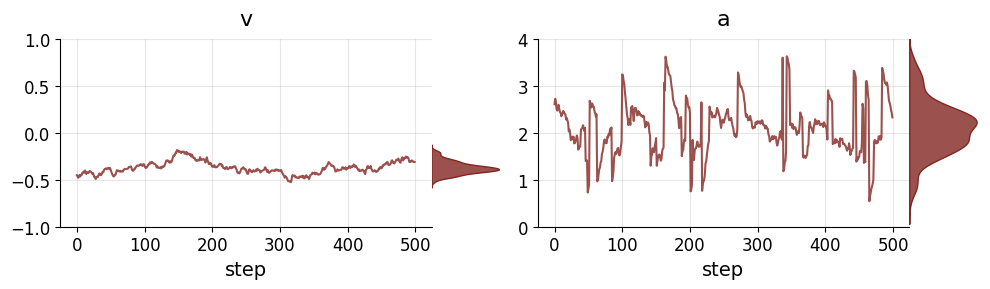

In [80]:
p = joint_prior.plot_time_varying_prior(
    steps = 500,
    num_trajectories=1
)

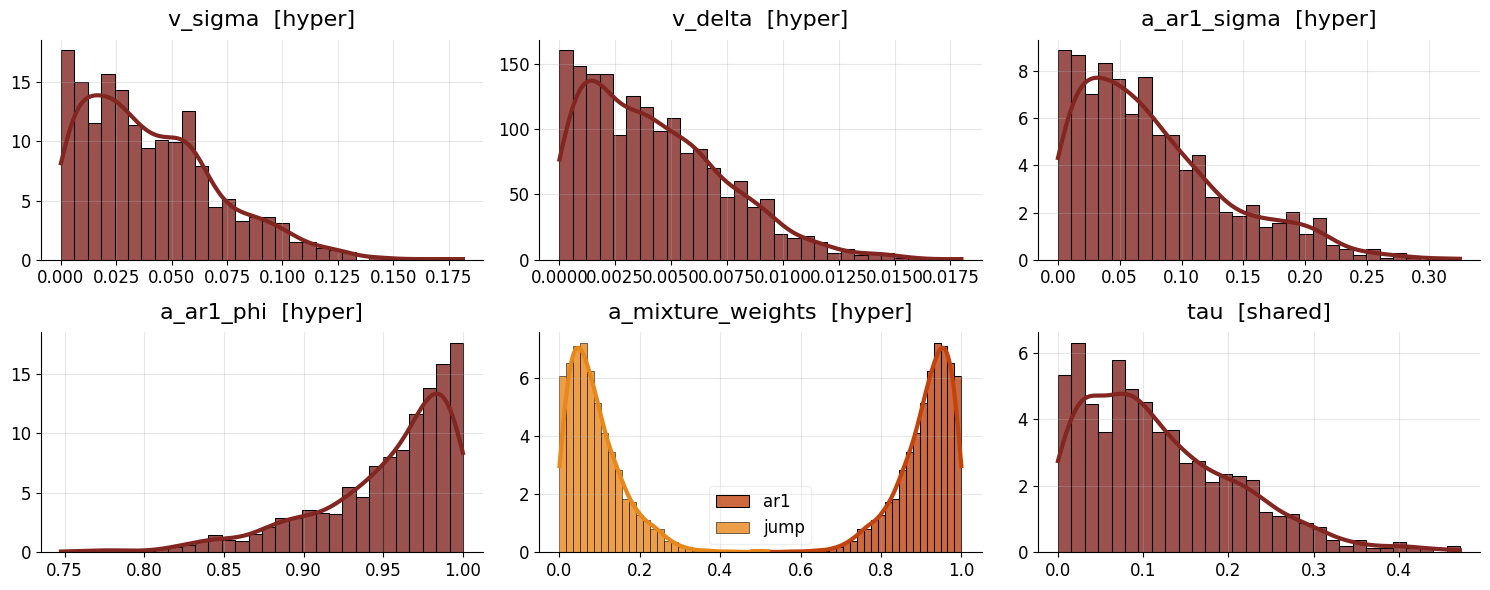

In [81]:
p = joint_prior.plot_time_invariant_prior(num_cols=3)

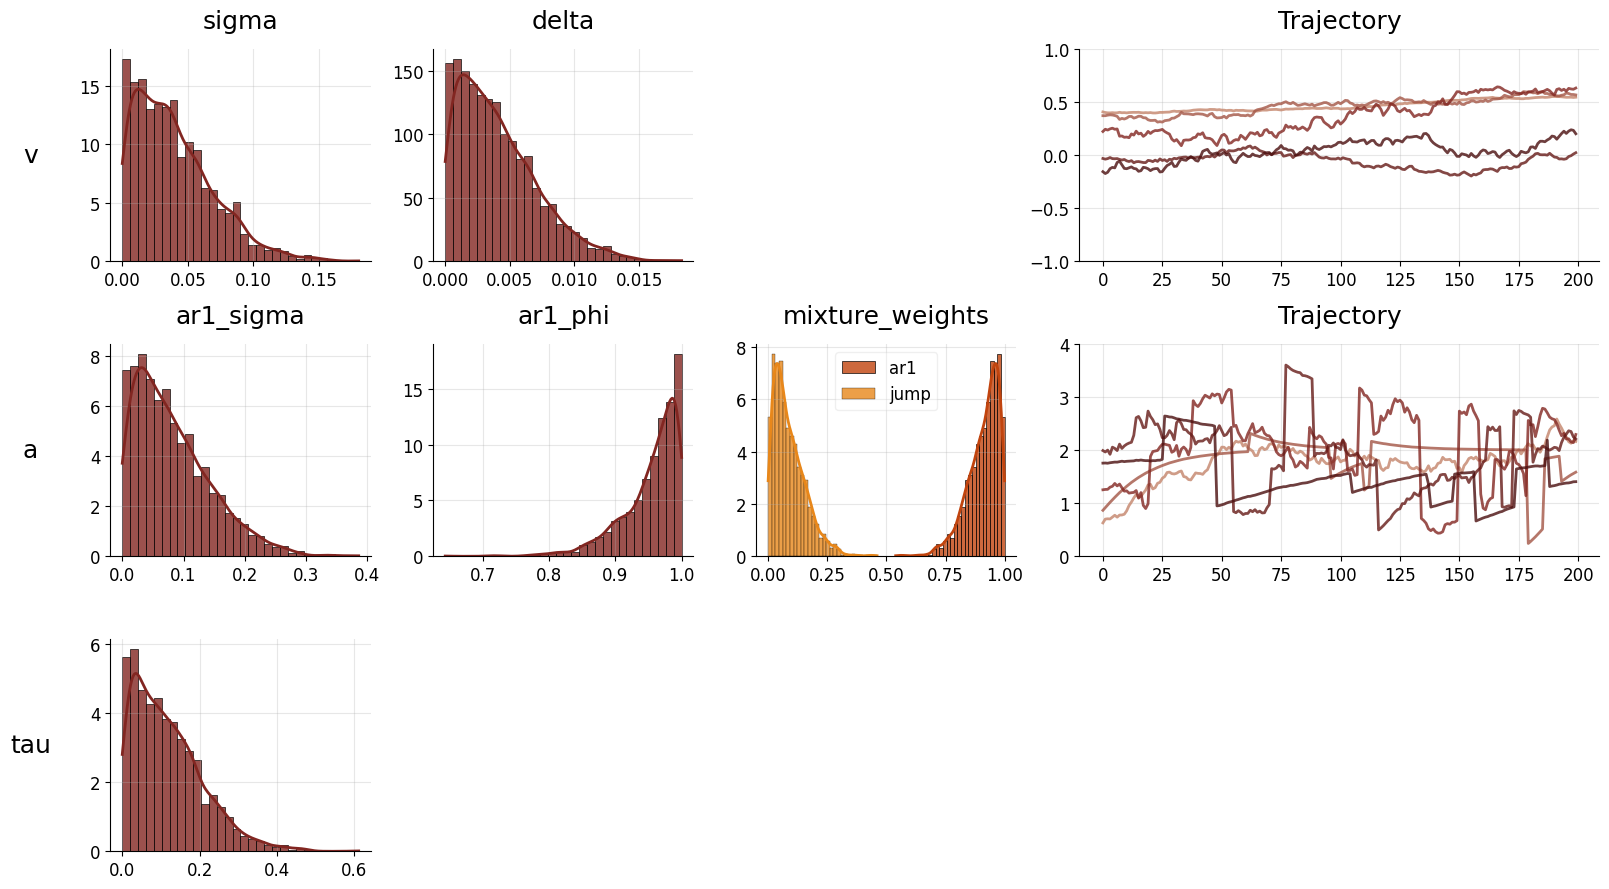

In [82]:
p = joint_prior.plot_joint_prior()

## Specify Generative Model

In [83]:
ddm = sup.simulation.sample_ddm

In [84]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

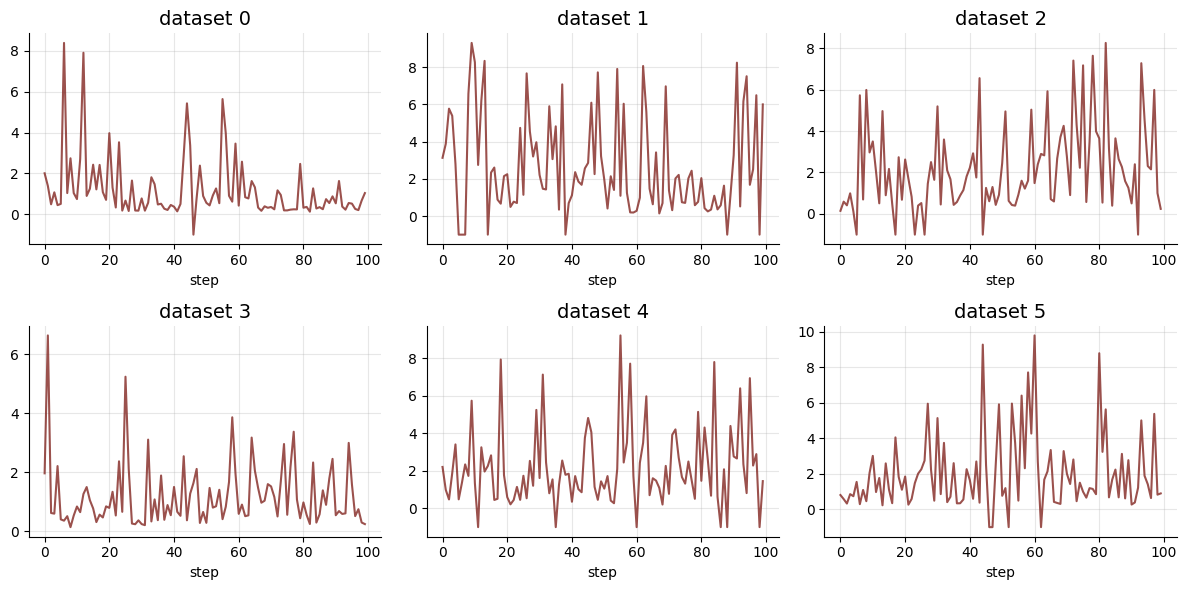

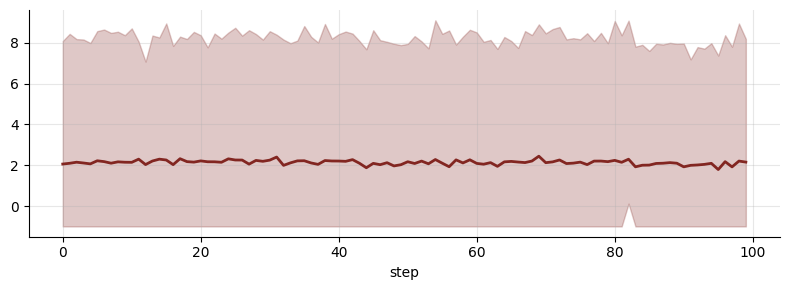

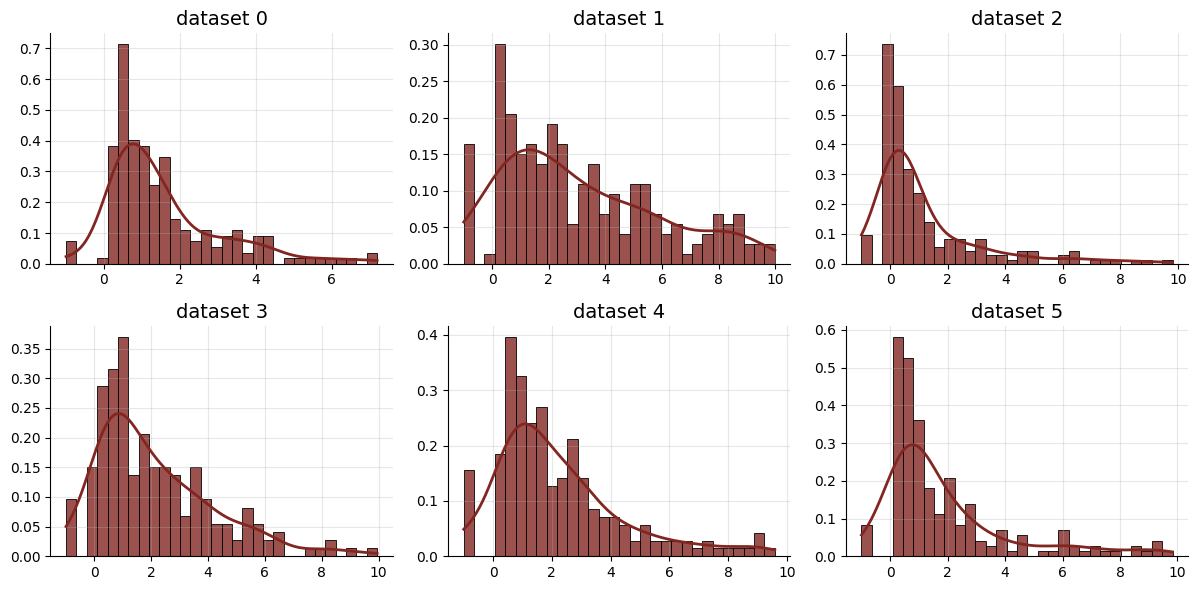

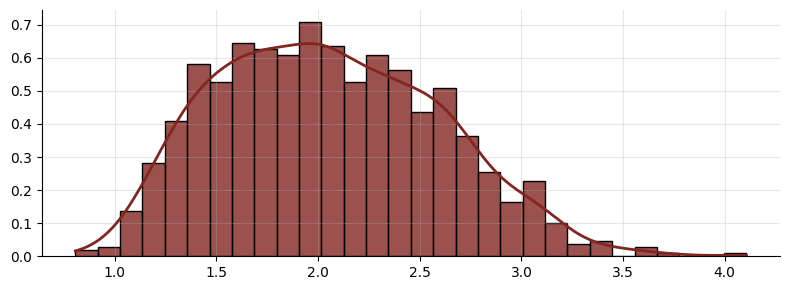

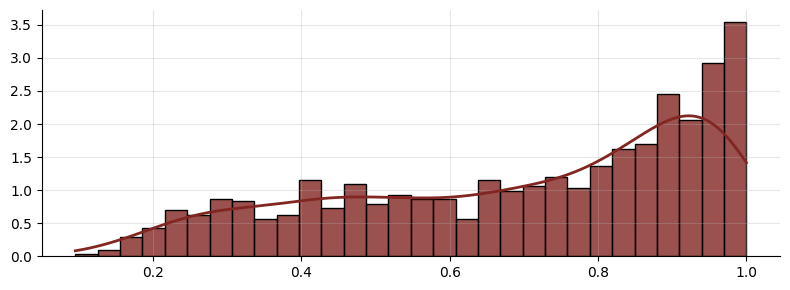

In [85]:
# 6 individual trajectories for data dim 0
plot = generative_model.plot_push_forward(
    batch_size=6,
    steps=100,
    data_dim=0,
    type="trajectory",
)

# mean + 95% CI across 500 trajectories
plot = generative_model.plot_push_forward(
    batch_size=500,
    steps=100,
    data_dim=0,
    type="trajectory",
    aggregate=True,
)

# 6 individual RT distributions
plot = generative_model.plot_push_forward(
    batch_size=6,
    steps=200,
    data_dim=0,
    type="hist",
)

# distribution of mean RT across 1000 datasets (default stats_fun)
plot = generative_model.plot_push_forward(
    batch_size=1000,
    steps=200,
    data_dim=0,
    type="hist",
    aggregate=True,
)

# distribution of choice proportions across 1000 datasets (binary dim)
plot = generative_model.plot_push_forward(
    batch_size=1000,
    steps=200,
    data_dim=1,
    type="hist",
    aggregate=True,
    stats_fun=lambda x: x.mean(axis=-1)
)


## Specify Workflow

- Discuss workflow wrapper with Stefan

In [ ]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="test",
)

### Offline Training

In [ ]:
workflow.fit_offline(
    train_data_size=20,
    test_data_size=5,
    steps=100,
    epochs=2,
    batch_size=2
)

In [ ]:
plot = workflow.plot_history()

In [ ]:
validation_data = workflow.generative_model.sample(batch_size=1, steps=100)

In [ ]:
samples = workflow.approximator.sample(conditions={"data": validation_data["data"]}, num_samples=100)

## Online Training

In [ ]:
workflow.fit_online(
    steps=200,
    epochs=4,
    num_batches_per_epoch=20,
    batch_size=10
)

In [ ]:
plot = workflow.plot_history()

## Validation

- `plot_time_variant_validation()`
- `plot_time_invariant_validation()`